In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification, make_blobs, make_circles
from sklearn.metrics import accuracy_score

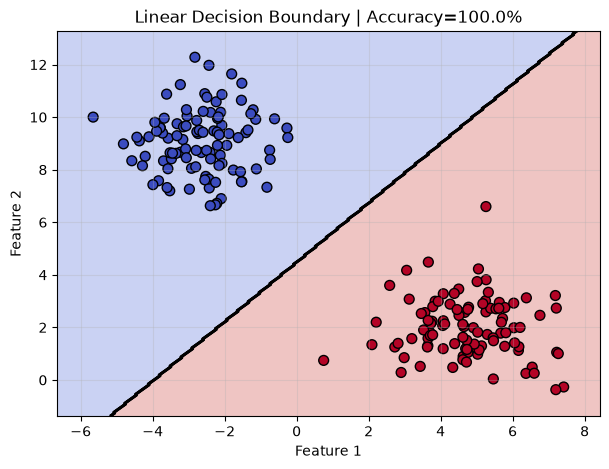

In [2]:
# Cell 2 — Version 1: linear decision boundary (2 features)
np.random.seed(42)
X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.2, random_state=42)

model = LogisticRegression()
model.fit(X, y)

# plot decision boundary
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.contour(xx, yy, Z, colors='black', linewidths=1.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=50)
plt.title(f'Linear Decision Boundary | Accuracy={accuracy_score(y, model.predict(X))*100:.1f}%')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3); plt.show()

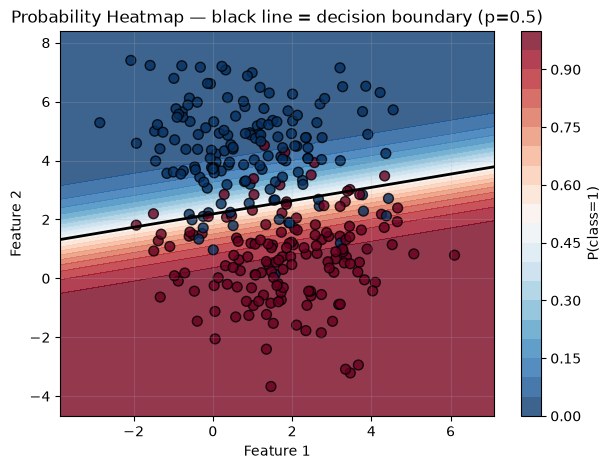

In [3]:
# Cell 3 — Version 2: probability heatmap (not just boundary)
np.random.seed(0)
X, y = make_blobs(n_samples=300, centers=2, cluster_std=1.5, random_state=0)

model = LogisticRegression()
model.fit(X, y)

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))

Z_prob = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

plt.figure(figsize=(7, 5))
cp = plt.contourf(xx, yy, Z_prob, levels=20, cmap='RdBu_r', alpha=0.8)
plt.colorbar(cp, label='P(class=1)')
plt.contour(xx, yy, Z_prob, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='RdBu_r', edgecolors='k', s=50, alpha=0.8)
plt.title('Probability Heatmap — black line = decision boundary (p=0.5)')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.grid(True, alpha=0.2); plt.show()

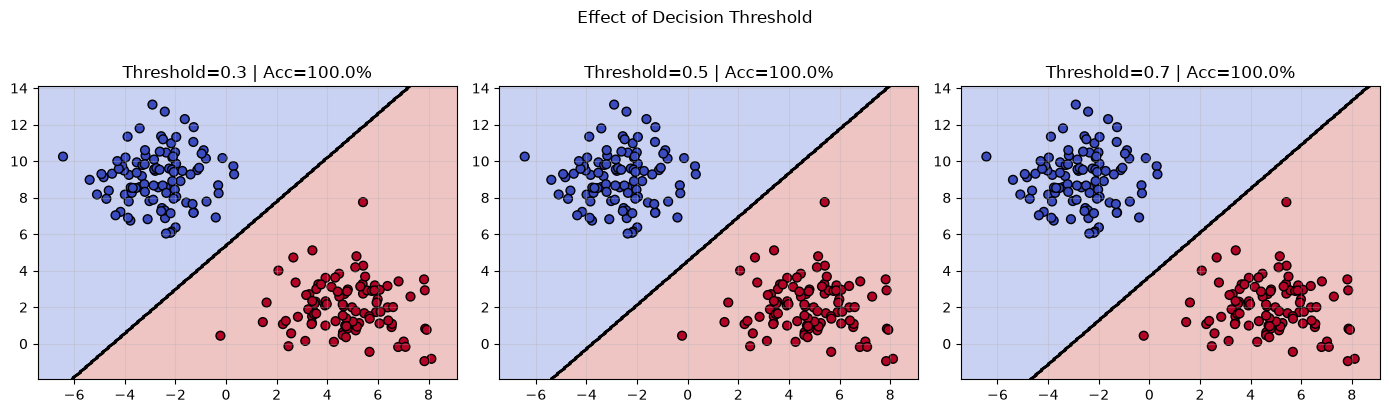

In [4]:
# Cell 4 — Version 3: effect of threshold on boundary
np.random.seed(42)
X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.5, random_state=42)

model = LogisticRegression()
model.fit(X, y)

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
Z_prob = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, thresh in zip(axes, [0.3, 0.5, 0.7]):
    Z = (Z_prob >= thresh).astype(int)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='black', linewidths=1.5)
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=40)
    preds = (model.predict_proba(X)[:,1] >= thresh).astype(int)
    ax.set_title(f'Threshold={thresh} | Acc={accuracy_score(y,preds)*100:.1f}%')
    ax.grid(True, alpha=0.3)
plt.suptitle('Effect of Decision Threshold', y=1.02)
plt.tight_layout(); plt.show()

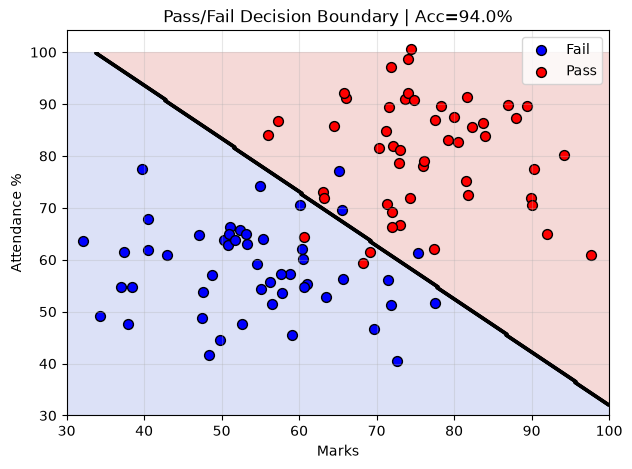

Student with 65 marks, 72% attendance → P(pass) = 0.72


In [5]:
# Cell 5 — Version 4: sklearn on real-style data (marks + attendance)
np.random.seed(7)
n = 100
marks      = np.concatenate([np.random.normal(55, 10, n//2),
                              np.random.normal(75, 10, n//2)])
attendance = np.concatenate([np.random.normal(60, 10, n//2),
                              np.random.normal(80, 10, n//2)])
y = np.array([0]*(n//2) + [1]*(n//2))   # 0=fail, 1=pass
X = np.column_stack([marks, attendance])

model = LogisticRegression()
model.fit(X, y)

xx, yy = np.meshgrid(np.linspace(30, 100, 300),
                     np.linspace(30, 100, 300))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.contour(xx, yy, Z, colors='black', linewidths=2)
plt.scatter(X[y==0,0], X[y==0,1], c='blue', label='Fail', edgecolors='k', s=50)
plt.scatter(X[y==1,0], X[y==1,1], c='red',  label='Pass', edgecolors='k', s=50)
plt.xlabel('Marks'); plt.ylabel('Attendance %')
plt.title(f'Pass/Fail Decision Boundary | Acc={accuracy_score(y, model.predict(X))*100:.1f}%')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# predict a new student
new_student = [[65, 72]]
prob = model.predict_proba(new_student)[0][1]
print(f"Student with 65 marks, 72% attendance → P(pass) = {prob:.2f}")